# CellChatPy analysis of spatial transcriptomics data

This tutorial demonstrates a complete CellChatPy workflow for one 10X Visium mouse cortex spatial transcriptomics dataset.

CellChatPy uses normalized gene expression, spot/cell annotations, spatial coordinates, spatial scale factors, and the ligand-receptor database to infer spatially proximal cell-cell communication.

The tutorial covers:

1. Load expression, metadata, full-resolution spatial coordinates, and Visium scale factors.
2. Create a spatial `CellChat` object and set the mouse ligand-receptor database.
3. Infer communication probabilities, pathway-level networks, and aggregated networks.
4. Visualize aggregate communication, IGF signaling, centrality, and spatial gene expression.
5. Export communication tables and the CellChat object.

## Setup and imports

The setup cell locates the repository from either the project root or `tutorial/`, imports the local `CellChatPy` package, and defines one helper that saves, displays, and closes each Matplotlib figure exactly once.

In [1]:
%matplotlib inline

from pathlib import Path
import pickle
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", message="divide by zero encountered in log")

project_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "CellChatPy").is_dir() and (path / "data").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Cannot locate a repository containing CellChatPy/ and data/.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import CellChatPy as cc

data_path = project_root / "data" / "mouse_cortex_visium.h5"
figure_dir = (project_root / "tutorial" / "figures_spatial_transcriptomics").resolve()
output_dir = (project_root / "tutorial" / "spatial_tutorial_output").resolve()
figure_dir.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None

    path = figure_dir / name
    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: {type(exc).__name__}: {exc}"
        ) from exc

    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)
    return None

print("CellChatPy:", cc.__version__)
print("Repository:", project_root)
print("Input:", data_path)

c:\anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CellChatPy: 1.1.0
Repository: E:\Jin\cellchat.python_new
Input: E:\Jin\cellchat.python_new\data\mouse_cortex_visium.h5


---

## Part I: Load and validate spatial inputs

For spatially resolved data, CellChat requires four inputs:

- `expression`: normalized expression with spots in rows and genes in columns.
- `metadata`: a table indexed by spot names with `cellchat_group` and `cellchat_dataset` columns.
- `coordinates`: full-resolution spot-centroid coordinates, indexed in the same order.
- `spatial_factors`: one positive `ratio` and `tol` value per dataset. `ratio` converts pixels to micrometers, while `tol` represents the spot-radius tolerance.

For 10X Visium, `ratio = 65 / spot_diameter_fullres` and `tol = 65 / 2`, where 65 micrometers is the theoretical spot diameter. The validation below makes matrix orientation and spot alignment explicit before analysis begins.

In [2]:
inputs = cc.read_spatial_h5(data_path)

data_input = inputs["expression"]
metadata = inputs["metadata"]
coordinates = inputs["coordinates"]
spatial_factors = inputs["spatial_factors"]
genes = [str(gene) for gene in inputs["genes"]]
spots = [str(spot) for spot in inputs["cells"]]

if data_input.shape != (len(spots), len(genes)):
    raise ValueError(
        "The expression matrix must have shape (number of spots, number of genes)."
    )
expression_values = data_input.data if hasattr(data_input, "data") else np.asarray(data_input)
if not np.isfinite(expression_values).all():
    raise ValueError("The expression matrix must contain only finite values.")
if len(set(spots)) != len(spots) or len(set(genes)) != len(genes):
    raise ValueError("Spot names and gene names must each be unique.")
if metadata.index.astype(str).tolist() != spots:
    raise ValueError("metadata must be indexed in the same order as the expression rows.")
if coordinates.index.astype(str).tolist() != spots:
    raise ValueError("coordinates must be indexed in the same order as the expression rows.")
required_columns = {"cellchat_group", "cellchat_dataset"}
missing_columns = required_columns.difference(metadata.columns)
if missing_columns:
    raise ValueError(f"metadata is missing required columns: {sorted(missing_columns)}")
if metadata[list(required_columns)].isna().any().any():
    raise ValueError("CellChat grouping and dataset labels cannot contain missing values.")
if not np.isfinite(coordinates.to_numpy(dtype=float)).all():
    raise ValueError("Spatial coordinates must contain only finite numeric values.")
dataset_count = metadata["cellchat_dataset"].nunique()
for factor_name in ("ratio", "tol"):
    factor = np.asarray(spatial_factors[factor_name], dtype=float).reshape(-1)
    if factor.size != dataset_count or not np.isfinite(factor).all() or np.any(factor <= 0):
        raise ValueError(
            f"spatial_factors[{factor_name!r}] must contain one finite positive value per dataset."
        )

print("Expression matrix (spots x genes):", data_input.shape)
print("Cell groups:")
display(metadata["cellchat_group"].value_counts(sort=False).to_frame("spots"))
print("Genes:", len(genes))
print("Spot diameter (micrometers):", spatial_factors["tol"][0] * 2)
print("ratio:", spatial_factors["ratio"][0])
print("tol:", spatial_factors["tol"][0])

Expression matrix (spots x genes): (1073, 433)
Cell groups:


,spots
cellchat_group,
Astro,136
L2/3 IT,199
L4,23
L5 IT,400
L6 CT,77
L6 IT,105
L6b,65
Oligo,68


Genes: 433
Spot diameter (micrometers): 65.0
ratio: 0.7264843252900255
tol: 32.5


Create a CellChat object from a data matrix
Cell groups used for CellChat analysis: ['Astro', 'L2/3 IT', 'L4', 'L5 IT', 'L6 CT', 'L6 IT', 'L6b', 'Oligo']
Create a CellChat object from spatial transcriptomics data...


c:\anaconda\envs\pytorch\Lib\site-packages\anndata\_core\anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\00_spatial_annotations.png


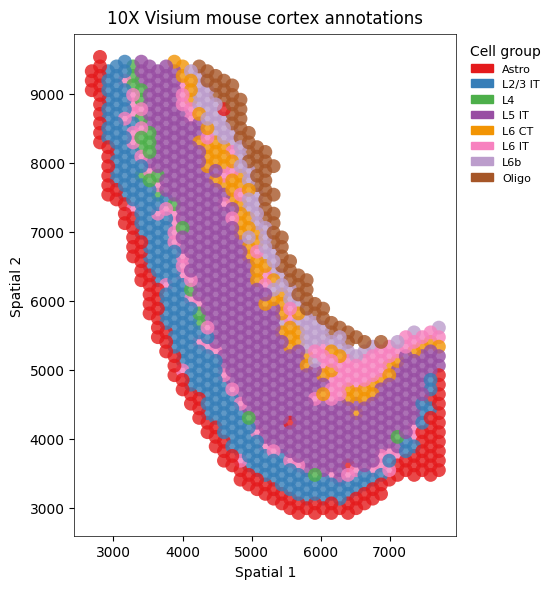

In [ ]:
cellchat = cc.create_cellchat(
    data_input,
    metadata=metadata,
    group_by="cellchat_group",
    datatype="spatial",
    coordinates=coordinates,
    spatial_factors=spatial_factors,
    genes=genes,
    cells=spots,
)

color_use = cc.sc_palette(len(cellchat.groups.categories))

fig = cc.plot_spatial_dim(
    cellchat,
    color_use=color_use,
    title_name="10X Visium mouse cortex annotations",
    pt_size=10,
    fig_size=(6, 6),
    return_fig=True,
)
save_fig(fig, "00_spatial_annotations.png")

### Inspect the spatial CellChat object

`create_cellchat` stores the expression matrix, labels, metadata, coordinates, and spatial factors in one object. Because the HDF5 expression matrix is sparse and carries no row or column labels itself, `genes` and `cells` are passed explicitly above. The annotation plot is also a useful early check that spot coordinates and cell-type labels agree.

In [4]:
print(cellchat)
print("Groups:", list(cellchat.groups.categories))

An object of class CellChat created from a single dataset
433 genes, 1073 cells
CellChat analysis of SPATIAL data!
The input spatial locations are:
                         0       1
AAACAGAGCGACTCCT-1  3164.0  7950.0
AAACCGGGTAGGTACC-1  6517.0  3407.0
AAACCGTTCGTCCAGG-1  7715.0  4371.0
AAACTCGTGATATAAG-1  4242.0  9258.0
AAAGGGATGTAGCAAG-1  4362.0  5747.0
Groups: ['Astro', 'L2/3 IT', 'L4', 'L5 IT', 'L6 CT', 'L6 IT', 'L6b', 'Oligo']


### Select the ligand-receptor database

For a new mouse analysis, use `cc.load_database("mouse")` and `cc.subset_database` to select the CellChatDB interactions used for inference. This example uses secreted signaling interactions.

The database is selected from the bundled CellChatDB tables so the same interaction definitions are used throughout the workflow. This tutorial follows the R vignette and analyzes the `Secreted Signaling` category.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\00_database_category.png


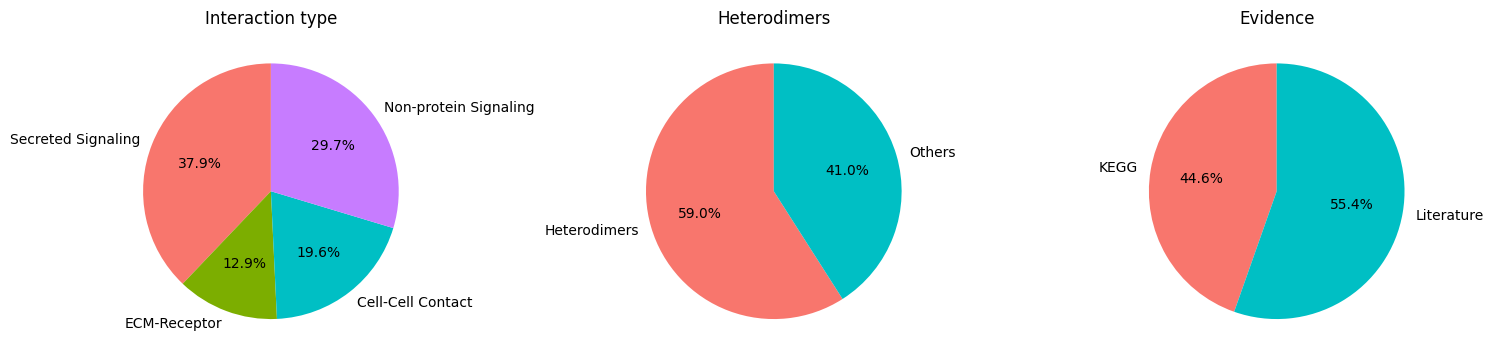

The number of highly variable ligand-receptor pairs used for signaling inference is 434
Ligand-receptor pairs used: 434
Signaling pathways: 62


,interaction_name,pathway_name,ligand,receptor,agonist,antagonist,co_A_receptor,co_I_receptor,annotation,interaction_name_2,...,receptor.symbol,receptor.family,receptor.location,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane,version
TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,Tgfb3,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,Tgfb3 - (Tgfbr1+Tgfbr2),...,"Tgfbr1, Tgfbr2","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Cell s...","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
TGFB3_ACVR1B_TGFBR2,TGFB3_ACVR1B_TGFBR2,TGFb,Tgfb3,ACVR1B_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,Tgfb3 - (Acvr1b+Tgfbr2),...,"Acvr1b, Tgfbr2","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
TGFB3_ACVR1C_TGFBR2,TGFB3_ACVR1C_TGFBR2,TGFb,Tgfb3,ACVR1C_TGFbR2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,Secreted Signaling,Tgfb3 - (Acvr1c+Tgfbr2),...,"Acvr1c, Tgfbr2","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Membrane","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
TGFB3_ACVR1_TGFBR1,TGFB3_ACVR1_TGFBR1,TGFb,Tgfb3,ACVR1_TGFbR,NaN,NaN,NaN,NaN,Secreted Signaling,Tgfb3 - (Acvr1+Tgfbr1),...,"Acvr1, Tgfbr1, Tgfbr2","Protein kinase superfamily, TKL Ser/Thr protei...","Cell membrane, Secreted, Membrane raft, Membra...","Membrane, Secreted, Disulfide bond, Kinase, Tr...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1
BMP2_BMPR1A_ACVR2A,BMP2_BMPR1A_ACVR2A,BMP,Bmp2,BMPR1A_ACVR2A,NaN,BMP antagonist,NaN,BMP inhibition receptor,Secreted Signaling,Bmp2 - (Bmpr1a+Acvr2a),...,"Bmpr1a, Acvr2a","Protein kinase superfamily, TKL Ser/Thr protei...","Membrane, Cell membrane, Cell surface","Membrane, Disulfide bond, Transmembrane, Kinas...",Receptors,Act.TGFB;Kinase,NaN,NaN,True,CellChatDB v1


In [5]:
db_mouse = cc.load_database("mouse")
fig = cc.show_database_category(db_mouse)
save_fig(fig, "00_database_category.png")

db_use = cc.subset_database(
    db_mouse,
    search="Secreted Signaling",
    key="annotation",
)
cellchat = cc.set_database(cellchat, database=db_use)
cellchat = cc.subset_signaling_data(cellchat)
cellchat = cc.identify_overexpressed_genes(cellchat)
cellchat = cc.identify_overexpressed_interactions(cellchat)

print("Ligand-receptor pairs used:", len(cellchat.lr_pairs["significant"]))
print("Signaling pathways:", cellchat.lr_pairs["significant"]["pathway_name"].nunique())
display(cellchat.lr_pairs["significant"].head())

### Inspect preprocessing results

The preceding cell reduces the expression matrix to signaling genes represented in the selected database, then identifies over-expressed genes and ligand-receptor interactions. The resulting `cellchat.lr_pairs["significant"]` table defines the interactions tested during communication inference.

---

## Part II: Infer spatial communication

This example follows the R spatial vignette with a 10% truncated mean, an interaction range of 250 micrometers, `scale_distance=0.01`, and a Visium contact range of 100 micrometers.

The tutorial uses `n_boot=20` for a reasonably quick demonstration. Increase the number of permutations for a final biological analysis when runtime permits.

In [6]:
n_boot = 20

started = time.time()

cellchat = cc.compute_communication_probability(
    cellchat,
    type_method="truncatedMean",
    trim=0.1,
    distance_use=True,
    interaction_range=250,
    scale_distance=0.01,
    k_min=10,
    contact_dependent=True,
    contact_range=100,
    n_boot=n_boot,
    seed_use=1,
)
cellchat = cc.filter_communication(cellchat, min_cells=10)
cellchat = cc.compute_pathway_probability(cellchat, thresh=0.05)
cellchat = cc.aggregate_network(cellchat, thresh=0.05)

print("Elapsed: %.2f seconds" % (time.time() - started))
print("LR networks:", len(cellchat.network["prob"]))
print("Pathways:", len(cellchat.pathway_network["prob"]))

truncatedMean is used for calculating the average gene expression per cell group.
Pre-computing 20 bootstrap averaged expressions...
Computing communication probabilities for 434 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
Pathway-level results stored in .pathway_network.
Elapsed: 19.75 seconds
LR networks: 434
Pathways: 40


### Extract significant communications

`subset_communication` returns significant ligand-receptor or pathway-level communications and can filter by source, target, signaling pathway, or ligand-receptor pair.

In [7]:
df_net = cc.subset_communication(cellchat, slot_name="network", thresh_pval=0.05)
df_pathway = cc.subset_communication(cellchat, slot_name="pathway_network", thresh_pval=0.05)

print("Significant LR communications:", len(df_net))
print("Pathway-level communications:", len(df_pathway))
display(df_net.head(10))

df_igf = cc.subset_communication(
    cellchat,
    slot_name="network",
    signaling="IGF",
    thresh_pval=0.05,
)
display(df_igf.head(10))

Significant LR communications: 1449
Pathway-level communications: 577


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,L4,L2/3 IT,Tgfb3,TGFbR1_R2,0.000551,0.05,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
1,L4,L4,Tgfb3,TGFbR1_R2,0.001117,0.05,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
2,L4,L5 IT,Tgfb3,TGFbR1_R2,0.000929,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
3,L4,L6 IT,Tgfb3,TGFbR1_R2,0.000562,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
4,L5 IT,L5 IT,Tgfb3,TGFbR1_R2,0.000662,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
5,L5 IT,L6 CT,Tgfb3,TGFbR1_R2,0.000314,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
6,L6 IT,Astro,Tgfb3,TGFbR1_R2,0.000314,0.05,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
7,L6 IT,L5 IT,Tgfb3,TGFbR1_R2,0.000846,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
8,L6 IT,L6 CT,Tgfb3,TGFbR1_R2,0.000532,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350
9,L6b,L5 IT,Tgfb3,TGFbR1_R2,0.000305,0.00,TGFB3_TGFBR1_TGFBR2,Tgfb3 - (Tgfbr1+Tgfbr2),TGFb,Secreted Signaling,KEGG: mmu04350


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,L2/3 IT,Astro,Igf1,Igf1r,0.001294,0.0,IGF1_IGF1R,Igf1 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
1,L2/3 IT,L2/3 IT,Igf1,Igf1r,0.002105,0.0,IGF1_IGF1R,Igf1 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
2,L2/3 IT,L5 IT,Igf1,Igf1r,0.000696,0.0,IGF1_IGF1R,Igf1 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
3,L2/3 IT,L6 IT,Igf1,Igf1r,0.000953,0.0,IGF1_IGF1R,Igf1 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
4,Astro,Astro,Igf2,Igf1r,0.000296,0.0,IGF2_IGF1R,Igf2 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
5,Astro,L2/3 IT,Igf2,Igf1r,0.000352,0.0,IGF2_IGF1R,Igf2 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
6,Astro,L6 IT,Igf2,Igf1r,0.000136,0.0,IGF2_IGF1R,Igf2 - Igf1r,IGF,Secreted Signaling,PMID: 14604834
7,Astro,L2/3 IT,Igf2,Igf2r,0.000076,0.0,IGF2_IGF2R,Igf2 - Igf2r,IGF,Secreted Signaling,PMID: 14604834
8,Astro,L6 IT,Igf2,Igf2r,0.000033,0.0,IGF2_IGF2R,Igf2 - Igf2r,IGF,Secreted Signaling,PMID: 14604834


In [8]:
lr_names = list(cellchat.network["prob"])
lr_prob = np.stack([cellchat.network["prob"][name].toarray() for name in lr_names], axis=2)
lr_pval = np.stack([cellchat.network["pval"][name] for name in lr_names], axis=2)

significant_prob = lr_prob.copy()
significant_prob[lr_pval > 0.05] = 0.0
count_check = np.sum(significant_prob > 0, axis=2)
weight_check = np.sum(significant_prob, axis=2)

np.testing.assert_array_equal(count_check, np.asarray(cellchat.network["count"]))
np.testing.assert_allclose(weight_check, np.asarray(cellchat.network["weight"]), atol=1e-14)

print("Aggregated count and weight are consistent with significant LR probabilities.")

Aggregated count and weight are consistent with significant LR probabilities.


---

## Part III: Visualize the communication network

The aggregate network summarizes significant ligand-receptor communication between each sender and receiver group. `count` is the number of significant LR pairs; `weight` is the sum of their communication probabilities.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\01_circle_count.png


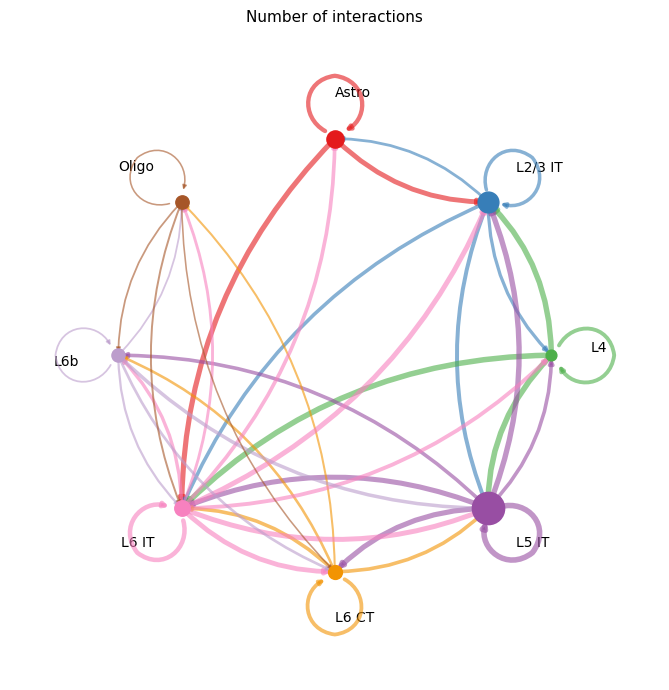

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\01_circle_weight.png


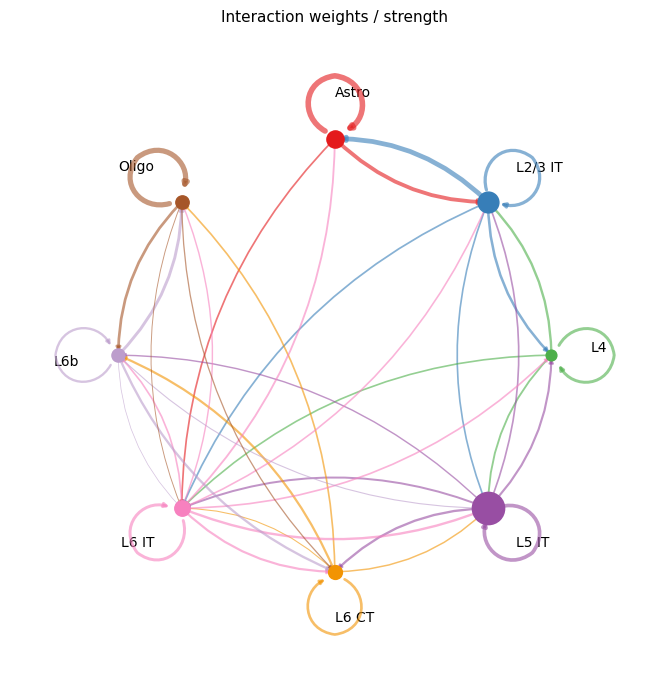

In [9]:
group_size = (
    metadata["cellchat_group"]
    .value_counts()
    .reindex(cellchat.groups.categories)
    .fillna(0)
    .to_numpy()
)

for matrix, title, filename in [
    (cellchat.network["count"], "Number of interactions", "01_circle_count.png"),
    (cellchat.network["weight"], "Interaction weights / strength", "01_circle_weight.png"),
]:
    fig = cc.plot_network_circle(
        cellchat,
        net_matrix=matrix,
        vertex_weight=group_size,
        weight_scale=True,
        title_name=title,
        fig_size=(7, 7),
        return_fig=True,
    )
    save_fig(fig, filename)

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\02_heatmap_count.png


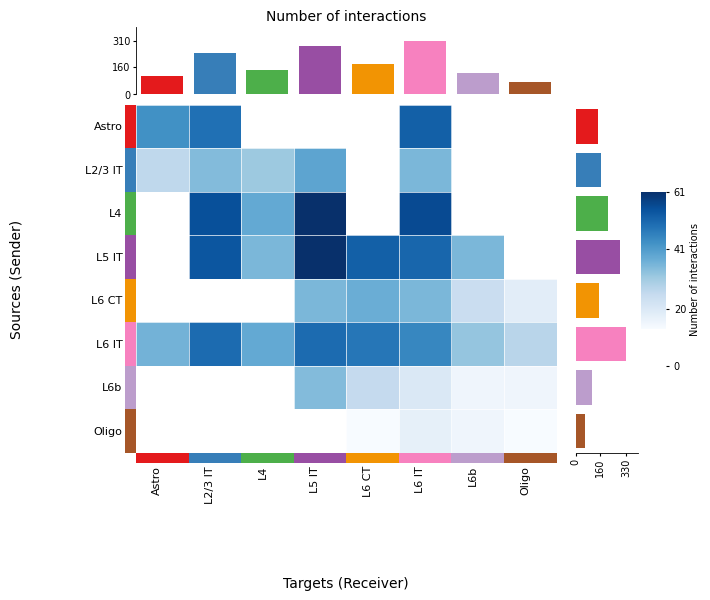

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\02_heatmap_weight.png


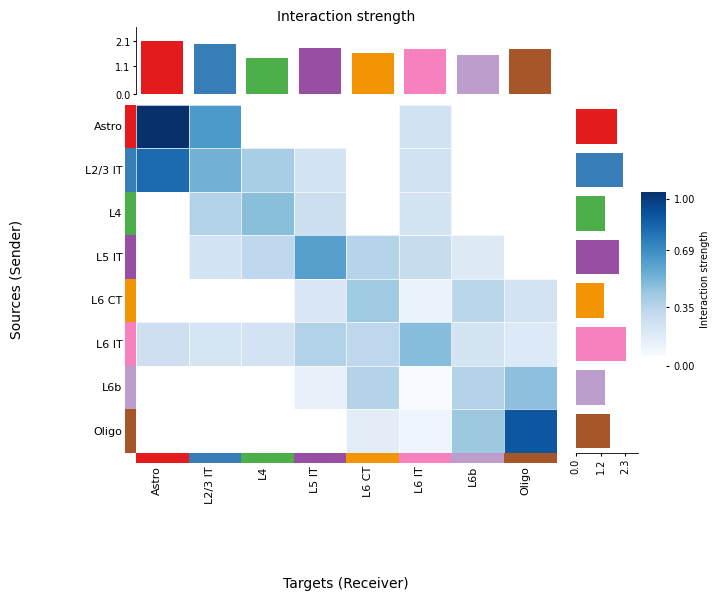

In [10]:
for measure, title, filename in [
    ("count", "Number of interactions", "02_heatmap_count.png"),
    ("weight", "Interaction strength", "02_heatmap_weight.png"),
]:
    fig = cc.plot_network_heatmap(
        cellchat,
        slot_name="network",
        measure=measure,
        color_heatmap="Blues",
        title_name=title,
        fig_size=(7, 6),
        return_fig=True,
    )
    save_fig(fig, filename)

### Visualize IGF signaling

CellChatPy can visualize a pathway-level network with a circle layout or a spatial layout. Here IGF is used as a representative pathway.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\03_circle_IGF.png


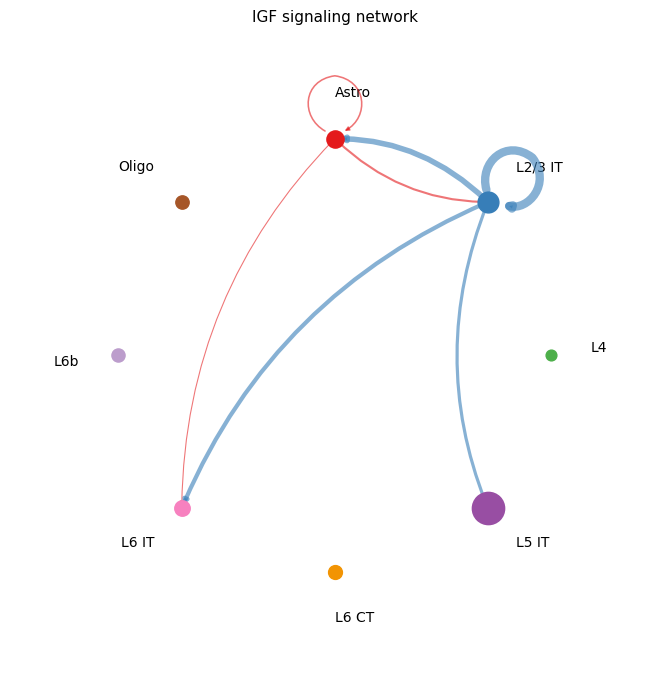

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\03_spatial_IGF.png


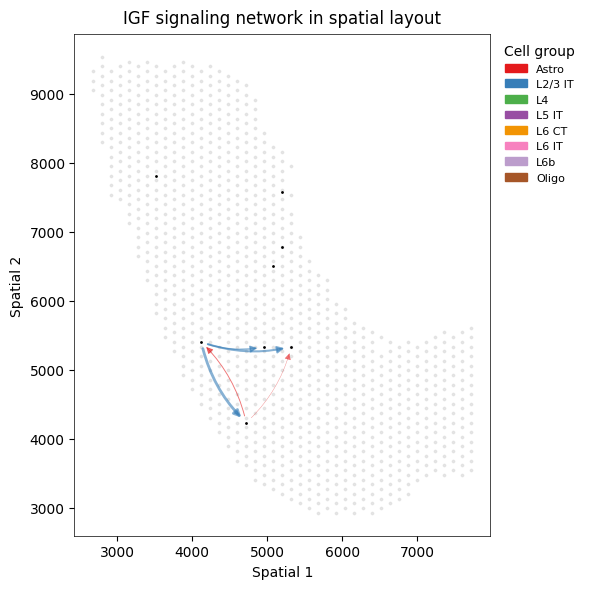

In [11]:
pathway_show = "IGF"
available_pathways = list(cellchat.pathway_network["prob"])
if pathway_show not in available_pathways:
    raise ValueError(
        f"{pathway_show!r} was not inferred. Available pathways: {available_pathways}"
    )

igf_matrix = cc.aggregate_signaling_matrix(cellchat, signaling=pathway_show)

fig = cc.plot_network_circle(
    cellchat,
    net_matrix=igf_matrix,
    title_name="IGF signaling network",
    edge_width_max=6,
    return_fig=True,
)
save_fig(fig, "03_circle_IGF.png")

fig = cc.plot_network_spatial(
    cellchat,
    signaling=pathway_show,
    edge_width_max=2,
    vertex_size_max=1,
    title_name="IGF signaling network in spatial layout",
    fig_size=(6, 6),
    return_fig=True,
)
save_fig(fig, "03_spatial_IGF.png")

### Compute signaling-role centrality

`compute_network_centrality` computes sender, receiver, mediator, and
influencer scores. `net_analysis_signaling_role_network` then displays
these scores for selected pathways.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\04_role_network_IGF.png


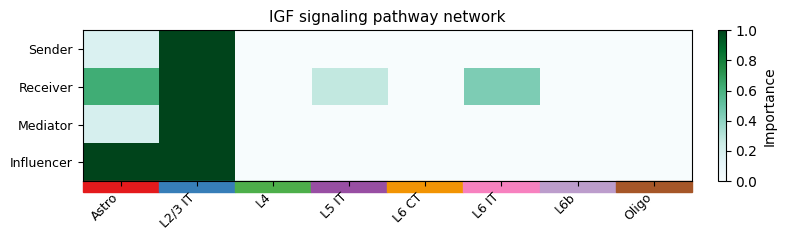

In [12]:
cellchat = cc.compute_network_centrality(cellchat, slot_name="pathway_network")

fig = cc.net_analysis_signaling_role_network(
    cellchat,
    signaling=pathway_show,
    slot_name="pathway_network",
    font_size=9,
    fig_size=(8, 2.5),
    return_fig=True,
)
save_fig(fig, "04_role_network_IGF.png")

### Plot spatial signaling-gene expression

`plot_spatial_feature` displays ligand and receptor expression on tissue coordinates for genes stored in the CellChat object. The explicit check below reports missing features instead of silently producing an incomplete panel.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\05_spatial_expression_Igf1_Igf1r.png


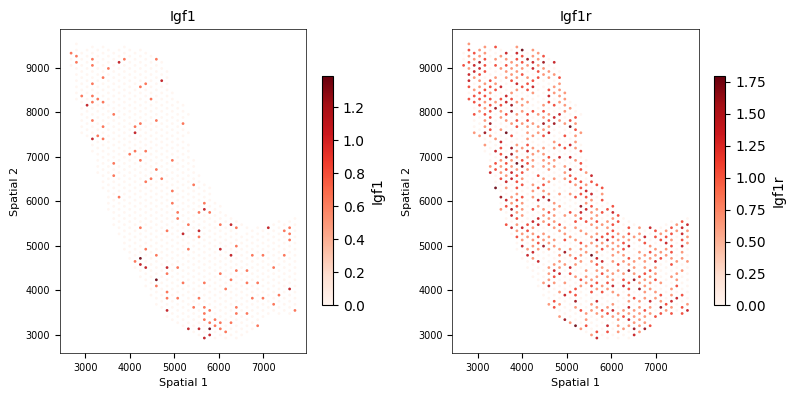

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_spatial_transcriptomics\05_spatial_expression_IGF.png


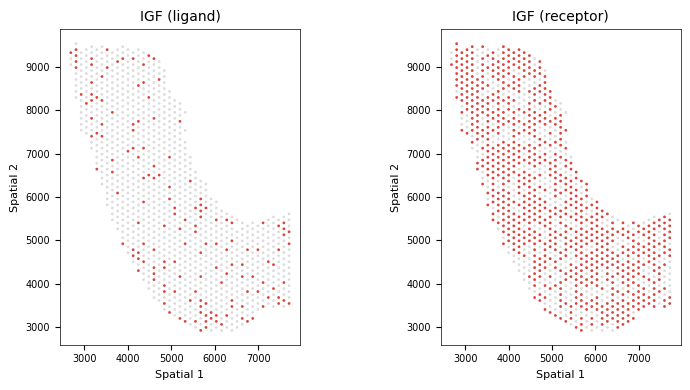

In [13]:
features_show = ["Igf1", "Igf1r"]
missing_features = [gene for gene in features_show if gene not in cellchat.var_names]
if missing_features:
    raise ValueError(f"Required IGF features are missing: {missing_features}")
else:
    fig = cc.plot_spatial_feature(
        cellchat,
        features=features_show,
        slot_data="x",
        color_bar="Reds",
        pt_size=2,
        ncol=2,
        fig_size=(8, 4),
        return_fig=True,
    )
    save_fig(fig, "05_spatial_expression_Igf1_Igf1r.png")

fig = cc.plot_spatial_feature(
    cellchat,
    signaling=pathway_show,
    color_use=["#d73027", "#d9d9d9"],
    pt_size=2,
    ncol=2,
    fig_size=(8, 4),
    return_fig=True,
)
save_fig(fig, "05_spatial_expression_IGF.png")

---

## Part IV: Save results

The communication table is convenient for inspection and downstream analysis. Pickle preserves the full Python `CellChat` object, while H5AD supports AnnData and Scanpy tooling. Export is opt-in so running the tutorial does not unexpectedly create large result files; set `export_results = True` when these artifacts are needed.

In [14]:
export_results = False

if export_results:
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / "cellchat_visium_interactions.csv"
    pkl_path = output_dir / "cellchat_visium_mouse_cortex.pkl"
    h5ad_path = output_dir / "cellchat_visium_mouse_cortex.h5ad"

    df_net.to_csv(csv_path, index=False)
    with open(pkl_path, "wb") as handle:
        pickle.dump(cellchat, handle, protocol=pickle.HIGHEST_PROTOCOL)
    cellchat.write_h5ad(h5ad_path)

    print("CSV:", csv_path)
    print("pickle:", pkl_path)
    print("h5ad:", h5ad_path)
else:
    print("Set export_results=True to write CSV, pickle and h5ad files.")

Set export_results=True to write CSV, pickle and h5ad files.


## Workflow summary

The complete CellChatPy workflow used in this notebook is:

1. Load spatial inputs with `read_spatial_h5`.
2. Create and configure a `CellChat` object.
3. Preprocess signaling features and infer communication probabilities.
4. Filter and aggregate the network.
5. Analyze centrality and visualize the results with the `plot_*` functions.

For other spatial technologies, derive `ratio`, `tol`, `interaction_range`, and the contact definition from that platform's physical geometry and image resolution. These values are part of the analysis model and should not be copied from Visium without checking their meaning.